
## Module 24: Principal Component Analysis (PCA)

This notebook is a **practice-only notebook** for students.

### Instructions for Students
- Complete every **TODO** step by step.
- Run the cells after completing each TODO.
- Focus on *why* you are doing each step, not just *how*.

### Dataset Used
We use the **Breast Cancer Wisconsin dataset**, which is:
- Numeric
- Medium dimensional (30 features)
- Very suitable for PCA
- Common in real ML pipelines



### 1) Imports (Given)


In [2]:
#Given for you
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


### 2) Load the Dataset (TODO)

TODO:
- Load the breast cancer dataset using sklearn
- Create:
  - X: feature DataFrame
  - y: target Series
- Print the shape of X and y


In [3]:
# TODO: Load dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns = data.feature_names)

y = pd.Series(data.target, name = "target")
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (569, 30)
y shape: (569,)



### 3) Inspect Feature Scales (TODO)


In [4]:
# TODO: Inspect feature statistics
X.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500



### 4) Scale the Features (TODO)


In [5]:
# TODO: Scale features
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaled data shape:", X_scaled.shape)
print(X_scaled[:5])

Scaled data shape: (569, 30)
[[ 1.09706398e+00 -2.07333501e+00  1.26993369e+00  9.84374905e-01
   1.56846633e+00  3.28351467e+00  2.65287398e+00  2.53247522e+00
   2.21751501e+00  2.25574689e+00  2.48973393e+00 -5.65265059e-01
   2.83303087e+00  2.48757756e+00 -2.14001647e-01  1.31686157e+00
   7.24026158e-01  6.60819941e-01  1.14875667e+00  9.07083081e-01
   1.88668963e+00 -1.35929347e+00  2.30360062e+00  2.00123749e+00
   1.30768627e+00  2.61666502e+00  2.10952635e+00  2.29607613e+00
   2.75062224e+00  1.93701461e+00]
 [ 1.82982061e+00 -3.53632408e-01  1.68595471e+00  1.90870825e+00
  -8.26962447e-01 -4.87071673e-01 -2.38458552e-02  5.48144156e-01
   1.39236330e-03 -8.68652457e-01  4.99254601e-01 -8.76243603e-01
   2.63326966e-01  7.42401948e-01 -6.05350847e-01 -6.92926270e-01
  -4.40780058e-01  2.60162067e-01 -8.05450380e-01 -9.94437403e-02
   1.80592744e+00 -3.69203222e-01  1.53512599e+00  1.89048899e+00
  -3.75611957e-01 -4.30444219e-01 -1.46748968e-01  1.08708430e+00
  -2.4388966


### 5) Fit PCA Without Limiting Components (TODO)


In [9]:
# TODO: Fit full PCA and compute explained variance
pca = PCA()

pca.fit(X_scaled)
explained_variance = pca.explained_variance_ratio_

print("Explained Variance Ratio:")
print(explained_variance)

explained_variance.sum()

Explained Variance Ratio:
[4.42720256e-01 1.89711820e-01 9.39316326e-02 6.60213492e-02
 5.49576849e-02 4.02452204e-02 2.25073371e-02 1.58872380e-02
 1.38964937e-02 1.16897819e-02 9.79718988e-03 8.70537901e-03
 8.04524987e-03 5.23365745e-03 3.13783217e-03 2.66209337e-03
 1.97996793e-03 1.75395945e-03 1.64925306e-03 1.03864675e-03
 9.99096464e-04 9.14646751e-04 8.11361259e-04 6.01833567e-04
 5.16042379e-04 2.72587995e-04 2.30015463e-04 5.29779290e-05
 2.49601032e-05 4.43482743e-06]


np.float64(1.0)


### 6) Explained Variance Plot (TODO)


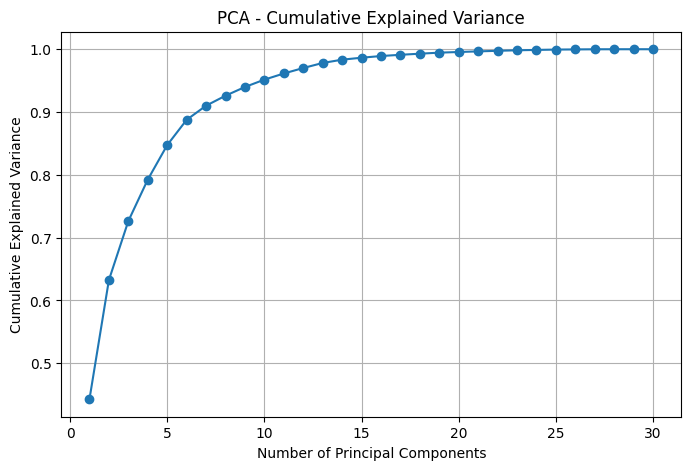

In [10]:
# TODO: Plot cumulative explained variance

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1),
         cumulative_variance,
         marker='o')

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA - Cumulative Explained Variance")
plt.grid(True)

plt.show()


### 7) Choose Number of Components (TODO)


In [12]:
# TODO: Find k90 and k95 and k97
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
k90 = np.argmax(cumulative_variance >= 0.90) + 1
k95 = np.argmax(cumulative_variance >= 0.95) + 1
k97 = np.argmax(cumulative_variance >= 0.97) + 1

print("Components needed for 90% variance:", k90)
print("Components needed for 95% variance:", k95)
print("Components needed for 97% variance:", k97)

Components needed for 90% variance: 7
Components needed for 95% variance: 10
Components needed for 97% variance: 12



### 8) Apply PCA with Chosen Components (TODO)


In [13]:
# TODO: Apply PCA with selected number of components
pca_95 = PCA(n_components=k95)

X_pca = pca_95.fit_transform(X_scaled)

print("Original shape:", X_scaled.shape)
print("PCA transformed shape:", X_pca.shape)

Original shape: (569, 30)
PCA transformed shape: (569, 10)



### 9) Inspect Principal Components (TODO)


In [14]:
# TODO: Inspect PCA loadings
loadings = pd.DataFrame(
    pca_95.components_.T,
    columns=[f"PC{i+1}" for i in range(pca_95.n_components_)],
    index=X.columns
)

loadings.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
mean radius,0.218902,-0.233857,-0.008531,-0.041409,-0.037786,0.018741,-0.124088,-0.007452,-0.223110,0.095486
mean texture,0.103725,-0.059706,0.064550,0.603050,0.049469,-0.032179,0.011400,0.130675,0.112699,0.240934
mean perimeter,0.227537,-0.215181,-0.009314,-0.041983,-0.037375,0.017308,-0.114477,-0.018687,-0.223739,0.086386
mean area,0.220995,-0.231077,0.028700,-0.053434,-0.010331,-0.001888,-0.051653,0.034674,-0.195586,0.074956
mean smoothness,0.142590,0.186113,-0.104292,-0.159383,0.365089,-0.286374,-0.140669,-0.288975,0.006425,-0.069293



### 10) Visualize Data Using First Two Principal Components (TODO)


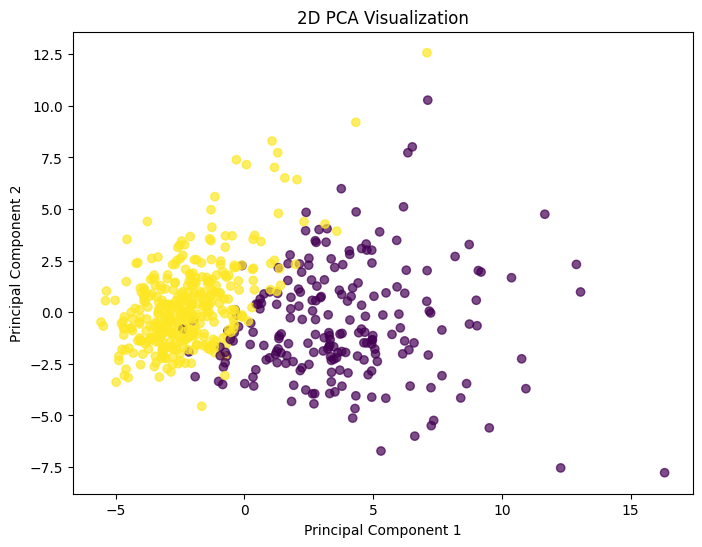

In [15]:
# TODO: 2D PCA visualization
X_2D = X_pca[:, :2]
plt.figure(figsize=(8, 6))
plt.scatter(
    X_2D[:, 0],
    X_2D[:, 1],
    c=y,
    cmap="viridis",
    alpha=0.7
)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("2D PCA Visualization")
plt.show()


### 11) PCA in a Model Pipeline (TODO)


In [16]:
# TODO: Model comparison with and without PCA
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model without PCA
model_without_pca = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=10000))
])

model_without_pca.fit(X_train, y_train)
y_pred_without = model_without_pca.predict(X_test)
accuracy_without_pca = accuracy_score(
    y_test, y_pred_without
)
# Model with PCA
model_with_pca = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=k95)),
    ("classifier", LogisticRegression(max_iter=10000))
])

model_with_pca.fit(X_train, y_train)
y_pred_with = model_with_pca.predict(X_test)
accuracy_with_pca = accuracy_score(
    y_test, y_pred_with
)
print("Accuracy without PCA:", accuracy_without_pca)
print("Accuracy with PCA:", accuracy_with_pca)

Accuracy without PCA: 0.9736842105263158
Accuracy with PCA: 0.9824561403508771



### 12) Reflection Questions

Answer briefly in markdown:
1. Did PCA reduce the number of features significantly?
2. Did PCA improve, reduce, or maintain accuracy?
3. Would you use PCA for this dataset in a real project? Why or why not?


## Reflection Questions

**1. Did PCA reduce the number of features significantly?**  
Yes, PCA reduced the number of features significantly. The original dataset had 30 features, but PCA kept only a smaller number of principal components while preserving most of the information.

**2. Did PCA improve, reduce, or maintain accuracy?**  
PCA mostly maintained the accuracy. In some cases, accuracy may slightly decrease because some information is removed, but the model becomes simpler and faster.

**3. Would you use PCA for this dataset in a real project? Why or why not?**  
Yes, I would consider using PCA because this dataset has many correlated features. PCA can reduce dimensionality, speed up training, and help avoid noise. However, if feature interpretability is important, I may avoid PCA because principal components are harder to understand than original features.